Import all requires library and utils

In [1]:
import copy
import json
import random
import time
import math
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from scipy import ndimage
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0
0.25.0


Configs class

In [26]:
@dataclass(slots=True)
class Config:
    model_name: str = ""
    data_dir: str = "./data"
    fast_mode: bool = False
    batch_size: int = 32
    n_show: int = 10
    seed: int = 42
    
cfg = Config()
cfg.fast_mode = True

Function that fix the seed

In [27]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(cfg.seed)

Define the device and quantity of epochs

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device: ', device)

EPOCHS = 4 if cfg.fast_mode else 12
print('Epochs: ', EPOCHS)

RUNS = pd.DataFrame(
    columns=[
        'experiment_id', 
        'task', 
        'dataset', 
        'seed', 
        'model_summary', 
        'optimizer',
        'lr',
        'epochs_trained',
        'best_val_accuracy',
        'test_accuracy',
        'precision',
        'recall',
        'mean_iou',
        'notes',
    ]
)
print(RUNS)

device:  cpu
Epochs:  4
Empty DataFrame
Columns: [experiment_id, task, dataset, seed, model_summary, optimizer, lr, epochs_trained, best_val_accuracy, test_accuracy, precision, recall, mean_iou, notes]
Index: []


Loading dataset CIFAR100

In [29]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

def loading_cifar100_dataset(
        train_transform: torchvision.transforms,
        test_transform: torchvision.transforms,
        data_dir: str = cfg.data_dir,
) -> Tuple[Dataset, Dataset]:
    
    train_dataset = torchvision.datasets.CIFAR100(data_dir, train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR100(data_dir, train=False, download=True, transform=test_transform)
    
    return train_dataset, test_dataset

default_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

ds_train, ds_test = loading_cifar100_dataset(
    default_transform,
    default_transform
)

class_names = ds_train.classes
print("len(class_names): ", len(class_names))
print("test len: ", len(ds_test))
print('Classes', class_names)

len(class_names):  100
test len:  10000
Classes ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip

Create function which separate train on train and val datasets

In [30]:
def make_loaders(
    ds_train: torch.utils.data.Dataset,
    ds_test: torch.utils.data.Dataset,
    seed: int = cfg.seed,
    fast_mode: bool = cfg.fast_mode,
    batch_size: int = cfg.batch_size,
    val_ratio: float = 0.2
):
    train_len = len(ds_train)
    val_len = int(train_len * val_ratio)
    train_len = train_len - val_len
    
    ds_train, ds_val = random_split(
        ds_train, 
        lengths=[train_len, val_len], 
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Fast-mode
    if fast_mode:
        rng = np.random.RandomState(cfg.seed)
        
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)
        
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test
        
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    ds_train,
    ds_test,
)

batch = next(iter(train_loader))
x, y = batch
print("x: ", x.shape, x.dtype)
print("y: ", y.shape, y.dtype)

/Users/mazxal/PycharmProjects/AI-Mirea-Course/homeworks/HW03/eda-cli/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


x:  torch.Size([32, 3, 32, 32]) torch.float32
y:  torch.Size([32]) torch.int64


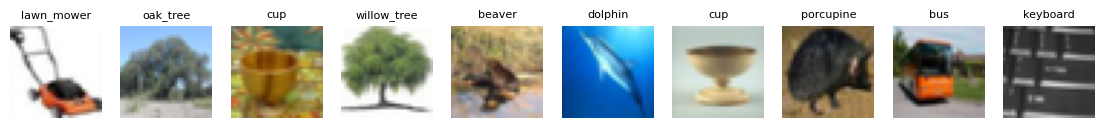

In [31]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, path_save: str = "") -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
        
    if path_save:
        plt.savefig(path_save)
    plt.show()
    
show_images(train_loader, n=cfg.n_show)

In [32]:
class CNNSimple(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32 x 32 -> 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2), # 32 x 32 -> 16 x 16
        
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16 x 16 -> 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(2), # 16 x 16 -> 8 x 8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 8 x 8 -> 8 x 8
            nn.ReLU(),
            nn.MaxPool2d(2), # 8 x 8 -> 4 x 4
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
        
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_simple = CNNSimple(num_classes=len(class_names)).to(device=device)
print(cnn_simple)
print("Quantity of model's parameters: ", count_params(cnn_simple))

CNNSimple(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Quantity of model's parameters:  643492


Definite the main function like fit, evaluate, train_one_epoch and etc

In [33]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(
        loader: DataLoader,
        model: nn.Module,
        optimizer: optim,
        criterion: nn.Module,
) -> Tuple[float, float]:
    model.train()
    
    total_loss, total_correct, total_seen = 0, 0, 0
    
    for x, y in loader:
        print("TRAIN!: ", total_seen / (len(loader) * cfg.batch_size) * 100)
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float] :
    model.eval()
    total_loss, total_accuracy, total_seen = 0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        
        bs = y.size(0)
        
        total_loss += (loss.item() * bs)
        total_accuracy += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_accuracy / total_seen

def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: nn.Module,
    criterion: nn.Module,
    epochs: int = 4,
    verbose: bool = True,    
) -> Dict:
    
    history = {
        "train_acc": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
    }
    
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            train_loader,
            model,
            optimizer,
            criterion,
        )
        
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
        )
        
        dt = time.time() - t0
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if verbose:
            print(
                f"Epochs: {epoch + 1:02d}/{epochs:02d}, time: {dt:.1f}s | "
                f"Train Loss: {train_loss:.4f}, train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, val Acc: {val_acc:.4f}"
            )
        
        if not math.isfinite(train_loss) or (not math.isfinite(val_loss)):
            print("NaN/Inf in loss - feature of problems with LR/stability. Stop fitting.")
            break
        
    return history

def plot_history(history: Dict[str, List[float]], title: str = "", save_dir: str = "") -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.title(title + " Training Loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(False)    
    plt.show()
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history['train_acc'], label="train accuracy")
    plt.plot(epochs, history['val_acc'], label="val accuracy")
    plt.title(title + " Training Accuracy")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(False)
    plt.show()
    
def plot_best_history(
    history: Dict[str, List[float]],
    title: str = "",
    save_path: str | None = None,
) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    axes[0].plot(epochs, history["train_loss"], label="train loss")
    axes[0].plot(epochs, history["val_loss"], label="val loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(False)

    axes[1].plot(epochs, history["train_acc"], label="train accuracy")
    axes[1].plot(epochs, history["val_acc"], label="val accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(False)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)
    
def run_experiment(
        experiment_id: str,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        criterion: nn.Module,
        dataset: str,
        model_name: str,
        notes: Optional[str] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        epochs: int = EPOCHS,
) -> Dict[str, Any]:
    
    model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr, 
        weight_decay=weight_decay
    )
    
    print("\n" + "=" * 80)
    print(f"Experiment {experiment_id} | lr={lr}, weight_decay={weight_decay}, epochs={epochs}")
    print("Trainable parameters:", count_params(model))
    
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs)
    best_val_acc = float(np.nanmax(hist['val_acc'])) if len(hist['val_acc']) else float("nan")
    
    return {
        "experiment_id": experiment_id,
        "model": model,
        "best_val_accuracy": best_val_acc,
        "history": hist,
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": epochs,
        "dataset": dataset,
        "model_summary": model_name,
        "notes": notes,
    }

def save_to_runs(
        experiment_run: Dict,
        runs: pd.DataFrame,
) -> pd.DataFrame:
    
    drop_fields = ["model", "history"]
    
    filtered_run = {k: v for k, v in experiment_run.items() if k not in drop_fields}
    
    experiment_run = pd.DataFrame([filtered_run])
    return pd.concat([runs, experiment_run], ignore_index=True)
    
def save_runs(
        runs: pd.DataFrame,
        path: str,
):
    runs.to_csv(path, index=False)
    
def save_json(data: dict, path: str) -> None:
    if not path.endswith(".json"):
        raise ValueError("must be .json")

    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    

In [34]:
criterion = nn.CrossEntropyLoss()


Experiment C1 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 643492
Epochs: 01/12, time: 62.6s | Train Loss: 3.6507, train Acc: 0.1427 | Val Loss: 3.1397, val Acc: 0.2291
Epochs: 02/12, time: 75.9s | Train Loss: 2.8596, train Acc: 0.2836 | Val Loss: 2.7357, val Acc: 0.3077
Epochs: 03/12, time: 66.3s | Train Loss: 2.4713, train Acc: 0.3610 | Val Loss: 2.5344, val Acc: 0.3538
Epochs: 04/12, time: 73.1s | Train Loss: 2.1932, train Acc: 0.4208 | Val Loss: 2.4566, val Acc: 0.3751
Epochs: 05/12, time: 62.3s | Train Loss: 1.9601, train Acc: 0.4716 | Val Loss: 2.4416, val Acc: 0.3836
Epochs: 06/12, time: 68.2s | Train Loss: 1.7542, train Acc: 0.5199 | Val Loss: 2.5034, val Acc: 0.3856
Epochs: 07/12, time: 64.5s | Train Loss: 1.5726, train Acc: 0.5623 | Val Loss: 2.5170, val Acc: 0.3937
Epochs: 08/12, time: 64.3s | Train Loss: 1.4027, train Acc: 0.6049 | Val Loss: 2.7318, val Acc: 0.3833
Epochs: 09/12, time: 76.9s | Train Loss: 1.2458, train Acc: 0.6434 | Val Loss: 2.8139, val A

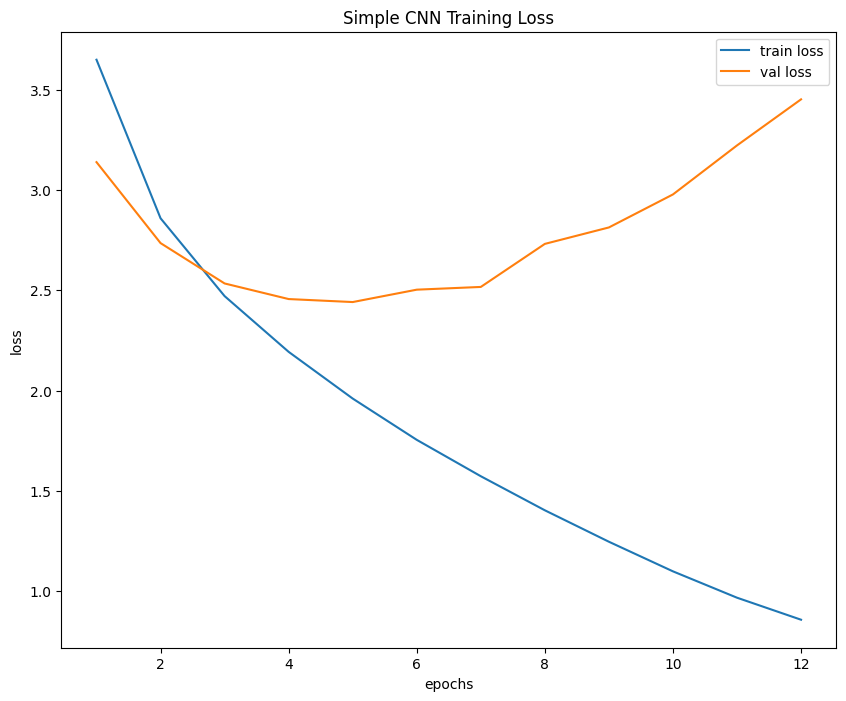

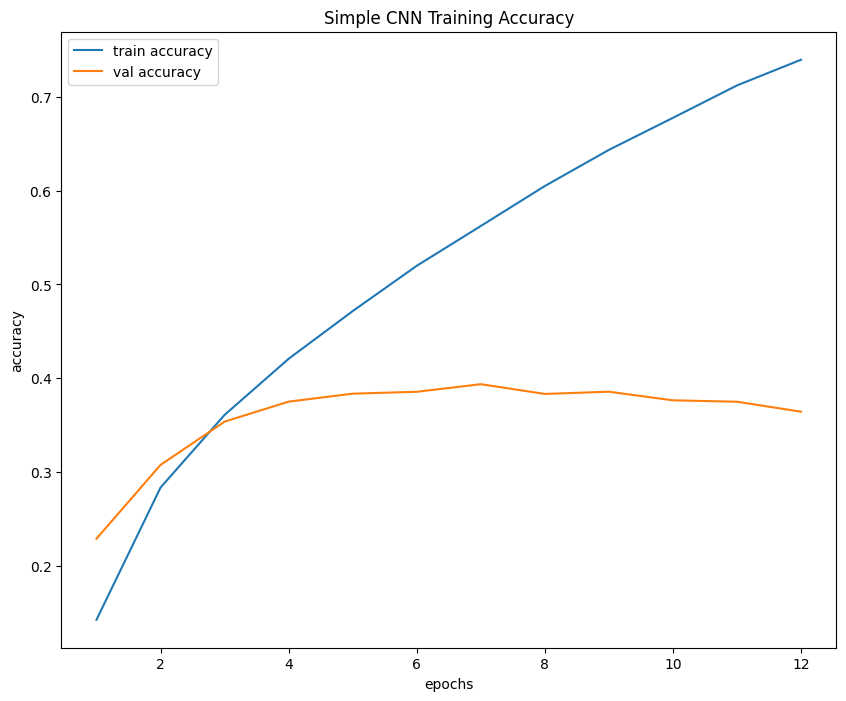

In [11]:
res_c1 = run_experiment(
    "C1",
    cnn_simple,
    train_loader,
    val_loader,
    criterion,
    dataset='cifar100',
    model_name="simple_cnn",
)
plot_history(res_c1["history"], title="Simple CNN")


Experiment C2 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 643492
Epochs: 01/12, time: 71.1s | Train Loss: 3.9577, train Acc: 0.0906 | Val Loss: 3.5780, val Acc: 0.1460
Epochs: 02/12, time: 70.3s | Train Loss: 3.4101, train Acc: 0.1813 | Val Loss: 3.2829, val Acc: 0.2049
Epochs: 03/12, time: 62.3s | Train Loss: 3.1425, train Acc: 0.2309 | Val Loss: 3.0682, val Acc: 0.2467
Epochs: 04/12, time: 68.3s | Train Loss: 2.9697, train Acc: 0.2629 | Val Loss: 2.9459, val Acc: 0.2649
Epochs: 05/12, time: 69.3s | Train Loss: 2.8529, train Acc: 0.2840 | Val Loss: 2.8520, val Acc: 0.2822
Epochs: 06/12, time: 75.8s | Train Loss: 2.7547, train Acc: 0.3025 | Val Loss: 2.7931, val Acc: 0.2979
Epochs: 07/12, time: 65.9s | Train Loss: 2.6848, train Acc: 0.3192 | Val Loss: 2.7376, val Acc: 0.3139
Epochs: 08/12, time: 75.2s | Train Loss: 2.6221, train Acc: 0.3331 | Val Loss: 2.7478, val Acc: 0.3057
Epochs: 09/12, time: 66.2s | Train Loss: 2.5678, train Acc: 0.3445 | Val Loss: 2.6672, val A

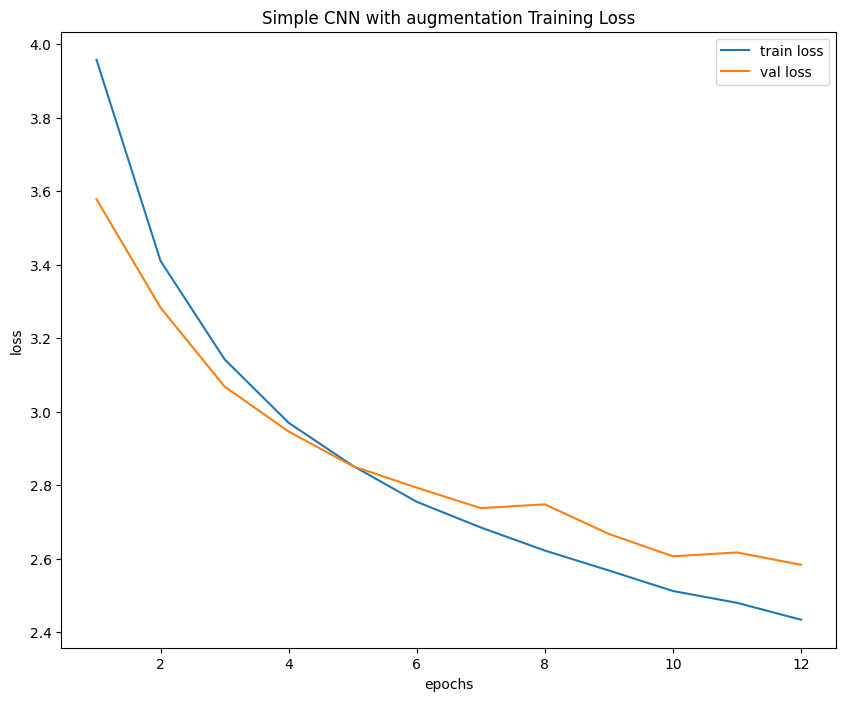

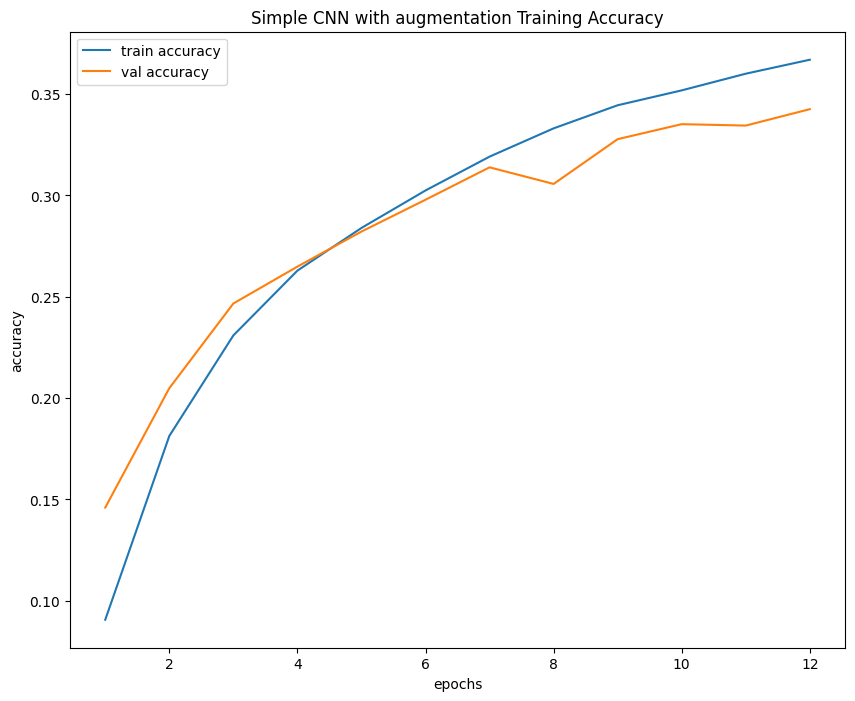

In [12]:
ds_train_aug, ds_test = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.RandomCrop(32, padding=4),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        torchvision.transforms.RandomRotation(10),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        torchvision.transforms.RandomErasing(p=0.1),
]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_aug, val_loader_aug, _ = make_loaders(
    ds_train_aug,
    ds_test,
)

cnn_simple_aug = CNNSimple(num_classes=len(class_names)).to(device=device)
res_c2 = run_experiment(
    "C2", 
    cnn_simple_aug, 
    train_loader_aug, 
    val_loader_aug, 
    criterion, 
    dataset='cifar100',
    model_name="simple_cnn",
    notes="with augmentation",
    lr=1e-3
)

plot_history(res_c2["history"], title="Simple CNN with augmentation")


Experiment C3 | lr=0.001, weight_decay=0.0, epochs=4
Trainable parameters: 51300
TRAIN!:  0.0
TRAIN!:  0.5319148936170213
TRAIN!:  1.0638297872340425
TRAIN!:  1.5957446808510638
TRAIN!:  2.127659574468085
TRAIN!:  2.6595744680851063
TRAIN!:  3.1914893617021276
TRAIN!:  3.723404255319149
TRAIN!:  4.25531914893617
TRAIN!:  4.787234042553192
TRAIN!:  5.319148936170213
TRAIN!:  5.851063829787234
TRAIN!:  6.382978723404255
TRAIN!:  6.914893617021277
TRAIN!:  7.446808510638298
TRAIN!:  7.9787234042553195
TRAIN!:  8.51063829787234
TRAIN!:  9.042553191489363
TRAIN!:  9.574468085106384
TRAIN!:  10.106382978723403
TRAIN!:  10.638297872340425
TRAIN!:  11.170212765957446
TRAIN!:  11.702127659574469
TRAIN!:  12.23404255319149
TRAIN!:  12.76595744680851
TRAIN!:  13.297872340425531
TRAIN!:  13.829787234042554
TRAIN!:  14.361702127659576
TRAIN!:  14.893617021276595
TRAIN!:  15.425531914893616
TRAIN!:  15.957446808510639
TRAIN!:  16.48936170212766
TRAIN!:  17.02127659574468
TRAIN!:  17.5531914893617
T

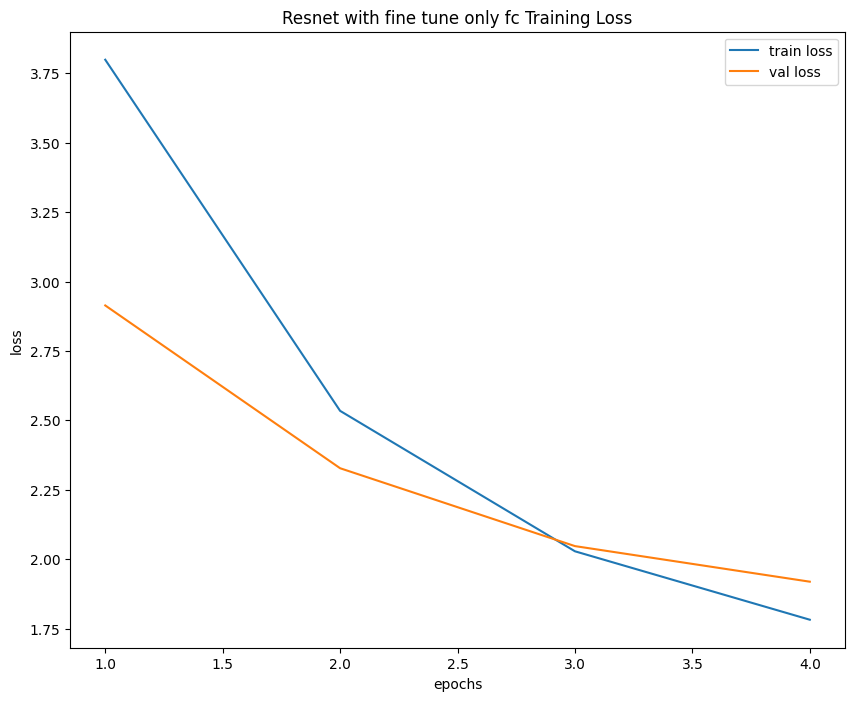

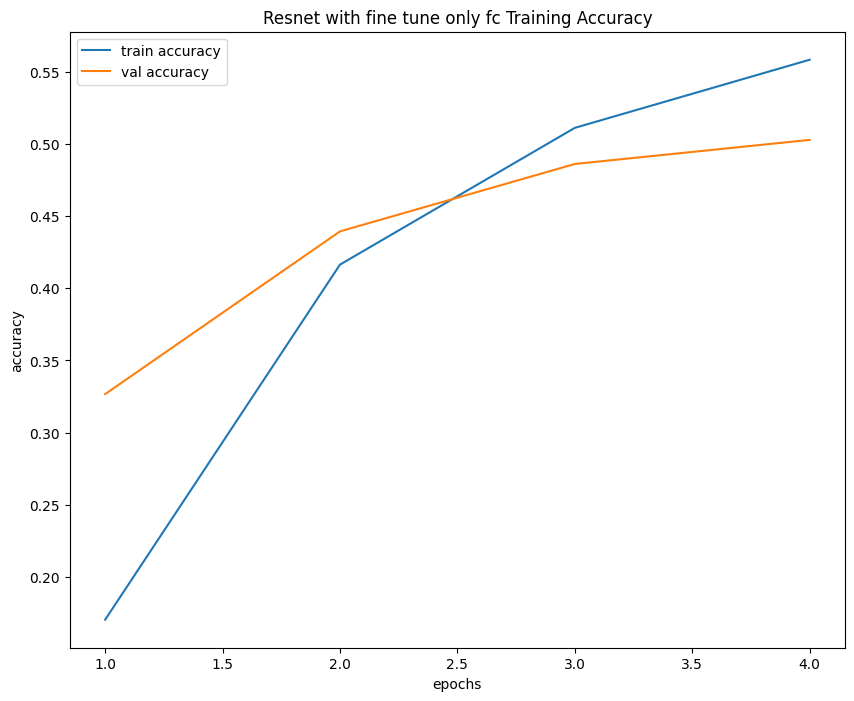

In [35]:
ds_train_for_resnet, ds_test_for_resnet = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders(
    ds_train_for_resnet,
    ds_test_for_resnet,
)

model_c3 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).to(device=device)
model_c3.fc = torch.nn.Linear(in_features=model_c3.fc.in_features, out_features=len(class_names))

model_c3.requires_grad_(False)
model_c3.fc.requires_grad_(True)

res_c3 = run_experiment(
    "C3", 
    model_c3, 
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune only fc",
)

plot_history(res_c3["history"], title="Resnet with fine tune only fc")


Experiment C4 | lr=0.001, weight_decay=0.0, epochs=4
Trainable parameters: 8445028
TRAIN!:  0.0
TRAIN!:  0.5319148936170213
TRAIN!:  1.0638297872340425
TRAIN!:  1.5957446808510638
TRAIN!:  2.127659574468085
TRAIN!:  2.6595744680851063
TRAIN!:  3.1914893617021276
TRAIN!:  3.723404255319149
TRAIN!:  4.25531914893617
TRAIN!:  4.787234042553192
TRAIN!:  5.319148936170213
TRAIN!:  5.851063829787234
TRAIN!:  6.382978723404255
TRAIN!:  6.914893617021277
TRAIN!:  7.446808510638298
TRAIN!:  7.9787234042553195
TRAIN!:  8.51063829787234
TRAIN!:  9.042553191489363
TRAIN!:  9.574468085106384
TRAIN!:  10.106382978723403
TRAIN!:  10.638297872340425
TRAIN!:  11.170212765957446
TRAIN!:  11.702127659574469
TRAIN!:  12.23404255319149
TRAIN!:  12.76595744680851
TRAIN!:  13.297872340425531
TRAIN!:  13.829787234042554
TRAIN!:  14.361702127659576
TRAIN!:  14.893617021276595
TRAIN!:  15.425531914893616
TRAIN!:  15.957446808510639
TRAIN!:  16.48936170212766
TRAIN!:  17.02127659574468
TRAIN!:  17.5531914893617

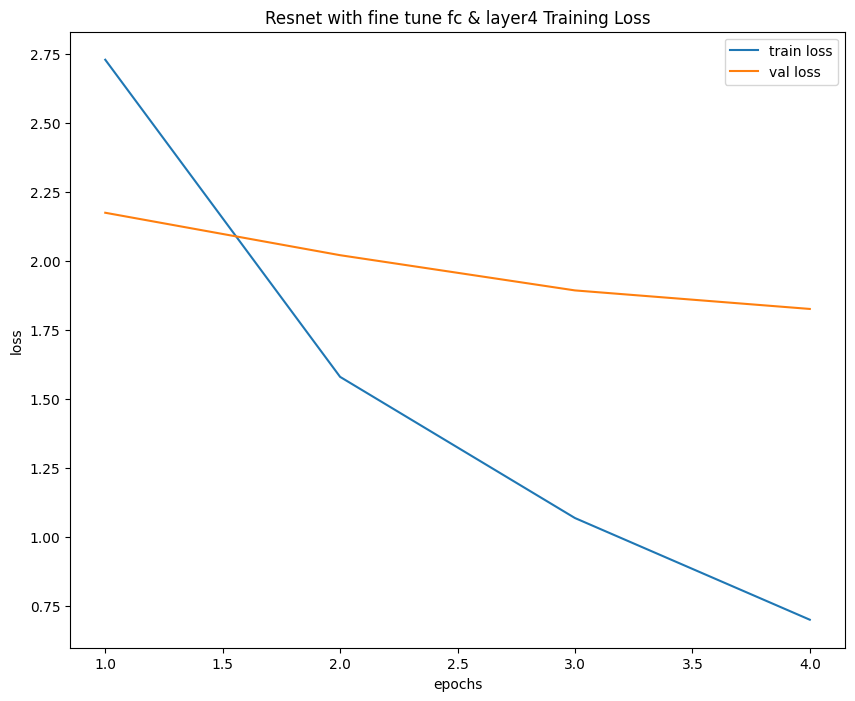

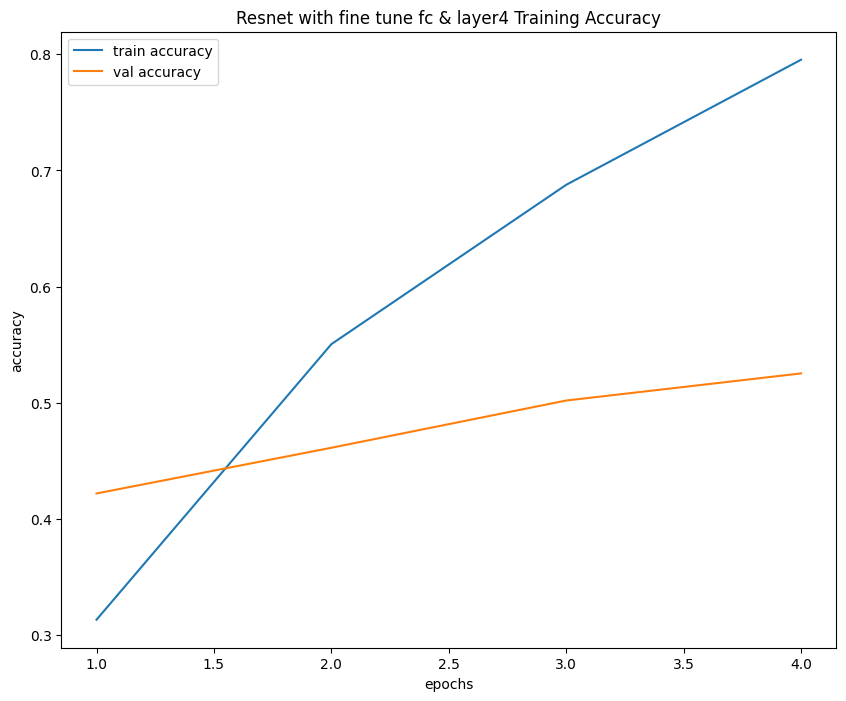

In [36]:
model_c4 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).to(device=device)
model_c4.fc = torch.nn.Linear(in_features=model_c4.fc.in_features, out_features=len(class_names))

model_c4.requires_grad_(False)
model_c4.layer4.requires_grad_(True)
model_c4.fc.requires_grad_(True)

res_c4 = run_experiment(
    "C4",
    model_c4,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune fc and layer4",
)

plot_history(res_c4['history'], title="Resnet with fine tune fc & layer4")

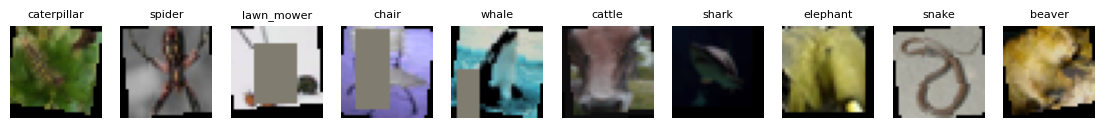

In [37]:
show_images(train_loader_aug, n=10, path_save="./artifacts/figures/augmentations_preview.png")

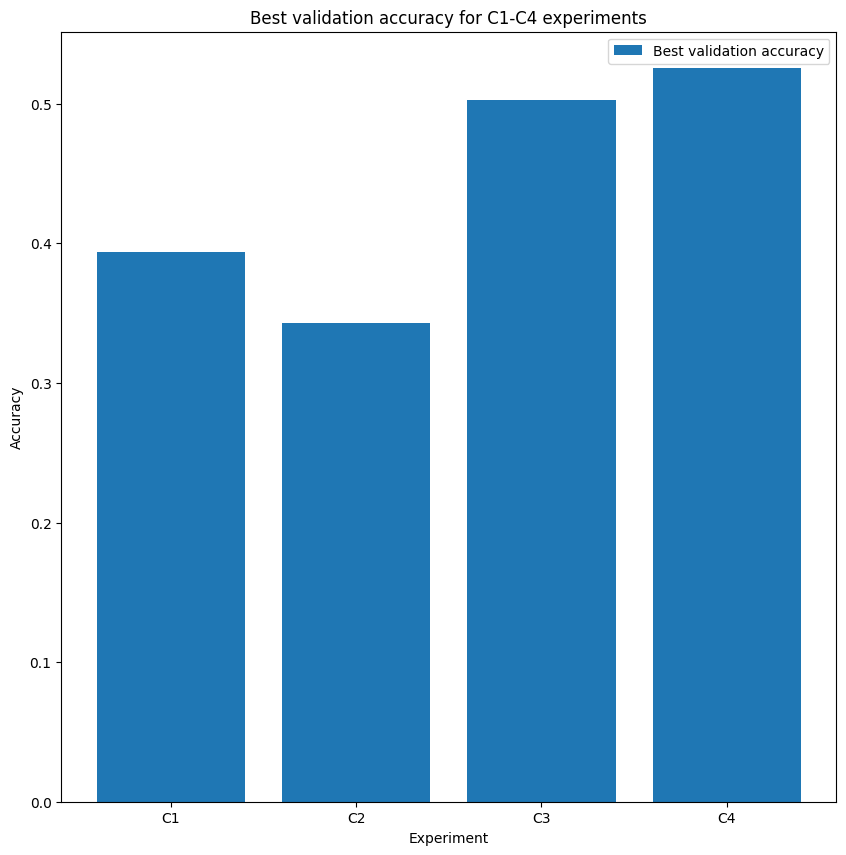

In [38]:
best_val_acc = [res_c1['best_val_accuracy'], res_c2['best_val_accuracy'], res_c3['best_val_accuracy'], res_c4['best_val_accuracy']]
experiment_names = ["C1", "C2", "C3", "C4"]

plt.figure(figsize=(10, 10))
plt.bar(experiment_names, best_val_acc, label="Best validation accuracy")
plt.title("Best validation accuracy for C1-C4 experiments")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(False)
plt.savefig("./artifacts/figures/classification_compare.png")
plt.show()

In [39]:
res_c1['test_accuracy'] = np.nan
res_c2['test_accuracy'] = np.nan
res_c3['test_accuracy'] = np.nan

test_loss, test_acc = evaluate(model_c4, test_loader_resnet, criterion)

res_c4['test_accuracy'] = test_acc

res_c1['seed'], res_c2['seed'], res_c3['seed'], res_c4['seed'] = [42] * 4
res_c1['task'], res_c2['task'], res_c3['task'], res_c4['task'] = ['classification'] * 4

In [40]:
res_c1

{'experiment_id': 'C1',
 'model': CNNSimple(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): ReLU()
     (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): ReLU()
     (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=2048, out_features=256, bias=True)
     (2): ReLU()
     (3): Linear(in_features=256, out_features=100, bias=True)
   )
 ),
 'best_val_accuracy': 0.3937,
 'history': {'train_acc': [0.1427,
   0.283575,
   0.361,
   0.420775,
   0.4716,
   0.519875,
   0.562275,
   0.6049,
   0.6434,
   0

In [41]:
RUNS = save_to_runs(res_c1, RUNS)
RUNS = save_to_runs(res_c2, RUNS)
RUNS = save_to_runs(res_c3, RUNS)
RUNS = save_to_runs(res_c4, RUNS)

/var/folders/t7/8q1snzfs15d4f28v56qswrkh0000gn/T/ipykernel_19738/2752048656.py:223: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([runs, experiment_run], ignore_index=True)


In [42]:
RUNS

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,cifar100,42,simple_cnn,Adam,0.001,12,0.393700,NaN,NaN,NaN,NaN,None
1,C2,classification,cifar100,42,simple_cnn,Adam,0.001,12,0.342600,NaN,NaN,NaN,NaN,with augmentation
2,C3,classification,cifar100,42,resnet_18,Adam,0.001,4,0.502667,NaN,NaN,NaN,NaN,with finetune only fc
3,C4,classification,cifar100,42,resnet_18,Adam,0.001,4,0.525333,0.504,NaN,NaN,NaN,with finetune fc and layer4


In [43]:
save_runs(RUNS, './artifacts/runs.csv')

In [44]:
torch.save(model_c4.state_dict(), './artifacts/best_classifier.pt')

In [45]:
best_res = copy.deepcopy(res_c4)
best_res['transformers'] = {
    "resize": 224,
    "normalize": True,
    "to_tensor": True
}

filter_fields = [
    'task', 'model', 'test_accuracy', 'history', 'best_val_accuracy',
]
[best_res.pop(x, None) for x in filter_fields]

save_json(best_res, './artifacts/best_classifier_config.json')

In [46]:
res_c4

{'experiment_id': 'C4',
 'model': ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

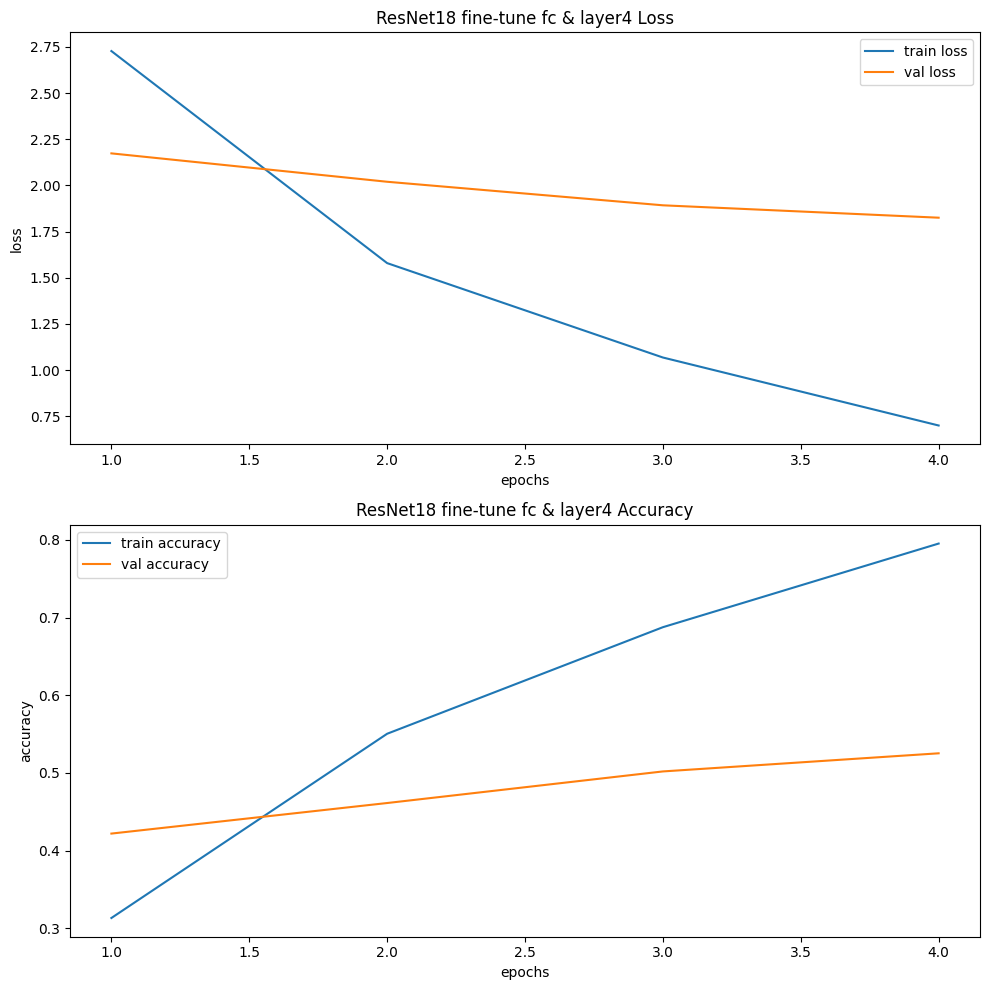

In [47]:
plot_best_history(
    res_c4["history"],
    title="ResNet18 fine-tune fc & layer4",
    save_path="./artifacts/figures/classification_curves_best.png",
)

# Here starts second part of homework (part-B)

In [48]:
import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation 
from torchvision.models.segmentation import fcn_resnet50

In [49]:
dataset = VOCSegmentation(
    root='./data',
    year='2012',
    image_set='train',
    download=True,
    transform=T.ToTensor(),
    target_transform=None,
)

img, mask = dataset[0]

In [50]:
print("image shape: ", img.shape)
mask_np = np.array(mask)
print("mask shape: ", mask_np.shape)
print("mask: ", np.unique(mask_np))

image shape:  torch.Size([3, 281, 500])
mask shape:  (281, 500)
mask:  [  0   1  15 255]


In [51]:
model = fcn_resnet50(weights=torchvision.models.segmentation.FCN_ResNet50_Weights.DEFAULT).to(device)
model.eval()

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [52]:
batch_img = img.unsqueeze(0)
with torch.no_grad():
    out = model(batch_img)
    print("out shape: ", out['out'].shape)
    predicted_mask = torch.argmax(out['out'], dim=1)
    print(predicted_mask.shape)
    print(np.unique(predicted_mask.cpu().numpy()))
    predicted_mask = predicted_mask.squeeze(0)

out shape:  torch.Size([1, 21, 281, 500])
torch.Size([1, 281, 500])
[ 0  1 15]


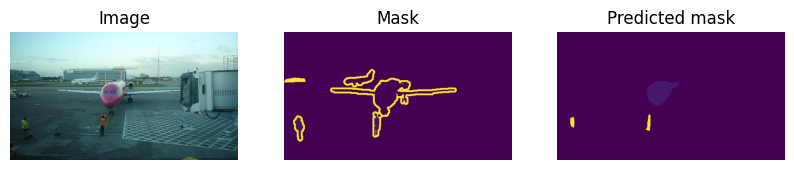

In [53]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np)
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask)
plt.title("Predicted mask")
plt.axis('off')

plt.savefig('./artifacts/figures/segmentation_examples.png')
plt.show()

In [54]:
def make_gt_fg_and_valid(mask):
    if not torch.is_tensor(mask):
        mask = torch.from_numpy(np.array(mask))
    else:
        mask = mask.clone()
        
    valid_mask = mask != 255
    gt_fg_mask = (mask != 0) & valid_mask
    return gt_fg_mask.bool(), valid_mask.bool()

def make_v1_mask(predict):
    
    if predict.ndim == 3 and predict.shape[0] == 1:
        predict = predict.squeeze(0)
        
    pred_fg_v1 = predict != 0
    return pred_fg_v1.bool()

def remove_small_components(binary_mask, min_size=500):
    labeled, num_futures = ndimage.label(binary_mask)
    result = np.zeros_like(binary_mask, dtype=bool)
    
    for label_id in range(1, num_futures + 1):
        component = labeled == label_id
        if component.sum() >= min_size:
            result |= component
            
    return result

def make_v2_mask(predict, min_size=500):
    pred_fg_v1 = make_v1_mask(predict)
    pred_fg_v1_np = pred_fg_v1.cpu().numpy().astype(bool)
    pred_fg_v2_np = remove_small_components(pred_fg_v1_np, min_size=min_size)
    pred_fg_v2 = torch.from_numpy(pred_fg_v2_np)
    
    return pred_fg_v2.bool()

def compute_iou(pred_fg_mask, gt_fg_mask, valid_mask):
    pred_valid = pred_fg_mask[valid_mask]
    gt_valid = gt_fg_mask[valid_mask]
    
    intersection = (pred_valid & gt_valid).sum().item()
    union = (pred_valid | gt_valid).sum().item()
    
    if union == 0:
        return 1.0
    
    return intersection / union

def evaluate_sample(img, mask, model, device=device, min_size=500):
    model.eval()
    
    batch_img = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(batch_img)
        predicted_mask = torch.argmax(out['out'], dim=1).squeeze(0).cpu()
        
    gt_fg_mask, valid_mask = make_gt_fg_and_valid(mask)
    
    pred_fg_v1 = make_v1_mask(predicted_mask)
    pred_fg_v2 = make_v2_mask(predicted_mask, min_size=min_size)
    
    iou_v1 = compute_iou(pred_fg_v1, gt_fg_mask, valid_mask)
    iou_v2 = compute_iou(pred_fg_v2, gt_fg_mask, valid_mask)
    
    return {
        'predicted_mask': predicted_mask,
        'gt_fg_mask': gt_fg_mask,
        'valid_mask': valid_mask,
        'pred_fg_v1': pred_fg_v1,
        'pred_fg_v2': pred_fg_v2,
        'iou_v1': iou_v1,
        'iou_v2': iou_v2
    }

In [55]:
sample_result = evaluate_sample(img, mask, model, device=device, min_size=500)
print("IoU V1:", sample_result["iou_v1"])
print("IoU V2:", sample_result["iou_v2"])
print("GT unique:", torch.unique(sample_result["gt_fg_mask"]))
print("Pred V1 unique:", torch.unique(sample_result["pred_fg_v1"]))
print("Pred V2 unique:", torch.unique(sample_result["pred_fg_v2"]))

IoU V1: 0.4641071428571429
IoU V2: 0.4014285714285714
GT unique: tensor([False,  True])
Pred V1 unique: tensor([False,  True])
Pred V2 unique: tensor([False,  True])


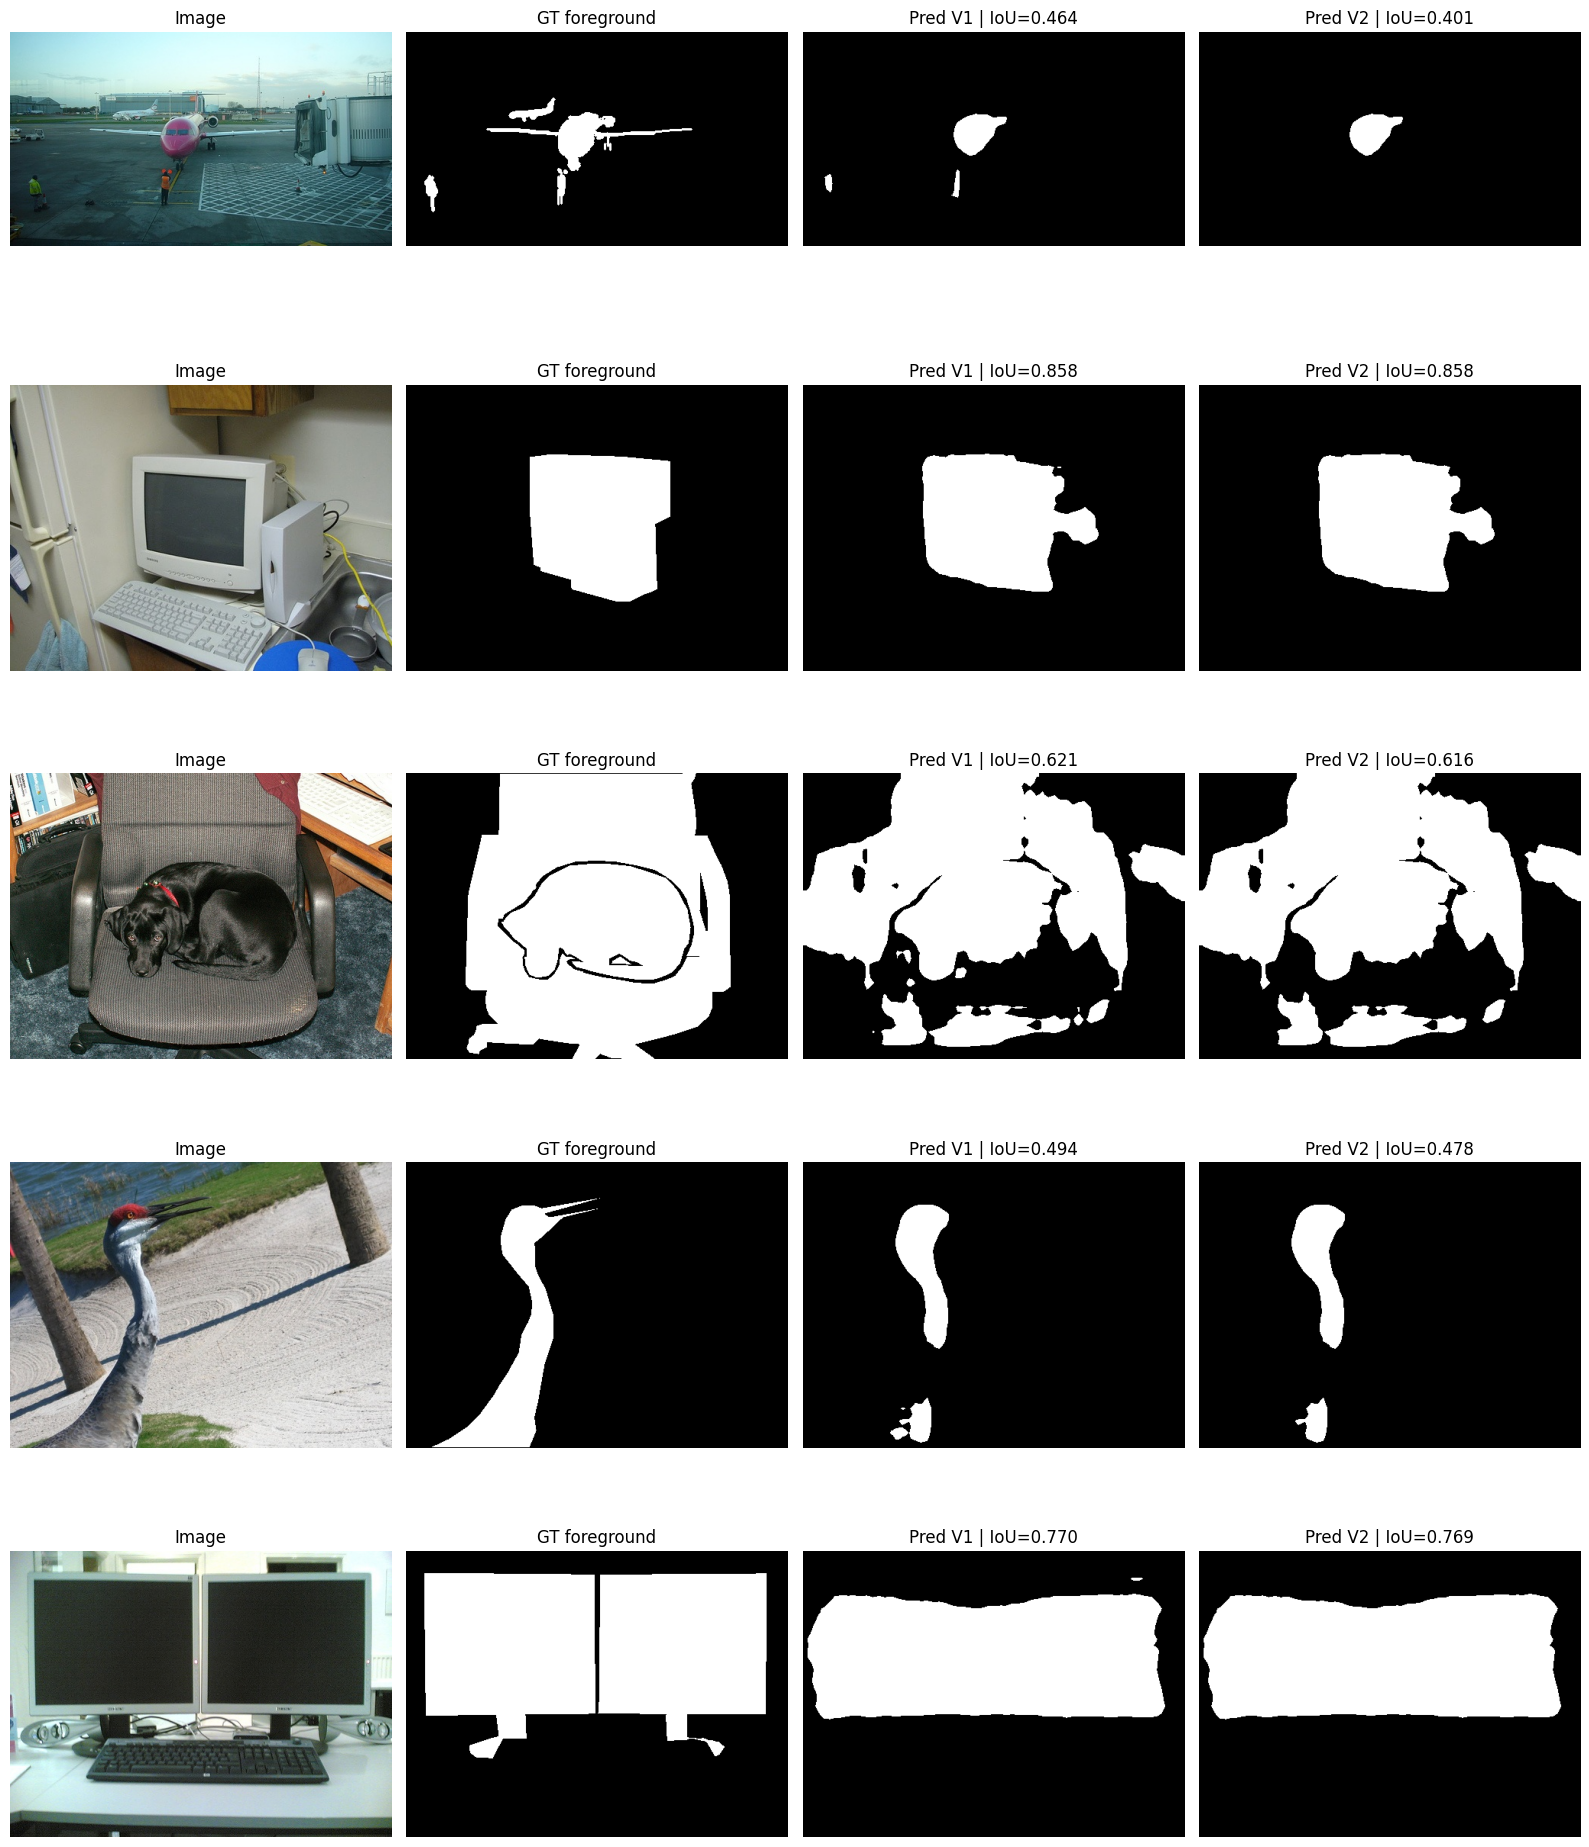

In [56]:
num_examples = 5

fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))

for i in range(num_examples):
    img_i, mask_i = dataset[i]
    sample_result = evaluate_sample(img_i, mask_i, model, device=device, min_size=500)

    axes[i, 0].imshow(img_i.permute(1, 2, 0))
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sample_result["gt_fg_mask"].cpu().numpy(), cmap="gray")
    axes[i, 1].set_title("GT foreground")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sample_result["pred_fg_v1"].cpu().numpy(), cmap="gray")
    axes[i, 2].set_title(f"Pred V1 | IoU={sample_result['iou_v1']:.3f}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(sample_result["pred_fg_v2"].cpu().numpy(), cmap="gray")
    axes[i, 3].set_title(f"Pred V2 | IoU={sample_result['iou_v2']:.3f}")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("./artifacts/figures/segmentation_examples.png")
plt.show()

In [57]:
results = []
num_samples = 20

for i in range(num_samples):
    img_i, mask_i = dataset[i]
    res = evaluate_sample(img_i, mask_i, model, device=device, min_size=500)

    results.append({
        "index": i,
        "iou_v1": res["iou_v1"],
        "iou_v2": res["iou_v2"],
    })

mean_iou_v1 = np.mean([r["iou_v1"] for r in results])
mean_iou_v2 = np.mean([r["iou_v2"] for r in results])

print("Mean iou v1: ", mean_iou_v1)
print("Mean iou v2: ", mean_iou_v2)

Mean iou v1:  0.7346707596590815
Mean iou v2:  0.728504311529315


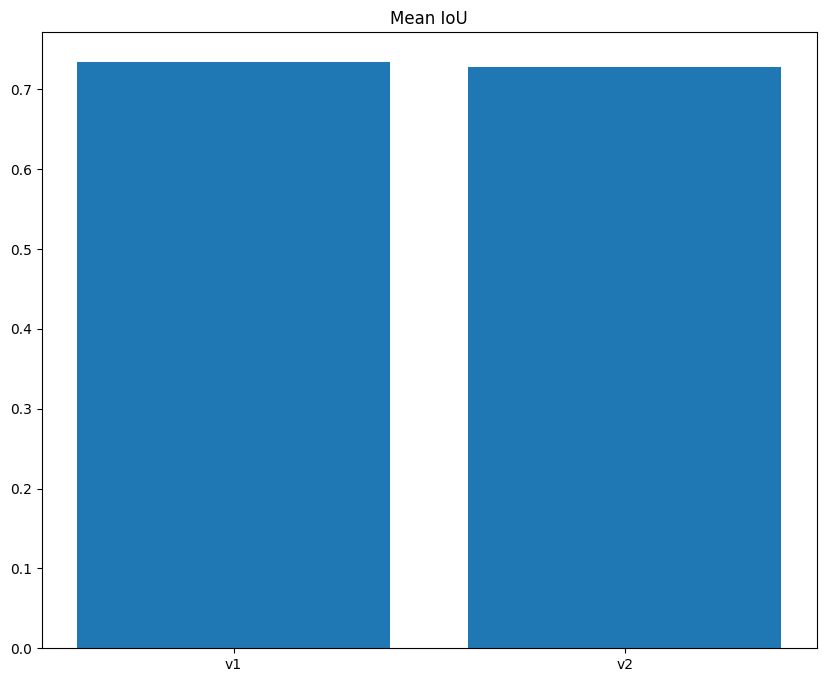

In [58]:
plt.figure(figsize=(10, 8))
plt.bar(['v1', 'v2'], [mean_iou_v1, mean_iou_v2], align='center')
plt.title("Mean IoU")
plt.savefig('./artifacts/figures/segmentation_metrics.png')
plt.show()

In [59]:
RUNS = save_to_runs({
    "experiment_id": "V1",
    "task": "segmentation",
    "seed": cfg.seed,
    "test_accuracy": np.nan,
    "model": model,
    "best_val_accuracy": 0,
    "optimizer": "",
    "lr": 0,
    "epochs_trained": 0,
    "dataset": "VOCSegmentation",
    "model_summary": "fcn_resnet50",
    "precision": np.nan,
    "recall": np.nan,
    "notes": "",
    "mean_iou": mean_iou_v1,
}, RUNS)

RUNS = save_to_runs({
    "experiment_id": "V2",
    "task": "segmentation",
    "seed": cfg.seed,
    "test_accuracy": np.nan,
    "model": model,
    "best_val_accuracy": 0,
    "optimizer": "",
    "lr": 0,
    "epochs_trained": 0,
    "dataset": "VOCSegmentation",
    "model_summary": "fcn_resnet50",
    "precision": np.nan,
    "recall": np.nan,
    "notes": "",
    "mean_iou": mean_iou_v2,
}, RUNS)

save_runs(RUNS, './artifacts/runs.csv')

/var/folders/t7/8q1snzfs15d4f28v56qswrkh0000gn/T/ipykernel_19738/2752048656.py:223: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([runs, experiment_run], ignore_index=True)
